In [1]:
import numpy as np

# Data handling
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
import sklearn

# Load training data.

The MNIST dataset is a collection of written digits compiled by the US Census Bureau who wanted an automated way to digitize written digits. It was released in 1994. The data are already divided into a training set (60,000 examples) and a test set (10,000 examples). 

Load the training data as a `pandas` `DataFrame`.

In [2]:
df_digits = pd.read_csv('mnist_train.csv',header=None)

In [3]:
df_digits.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 359.3 MB


The `DataFrame` has a built in method showing what kind of object it is, how many examples there are, and what the data types (`dtypes`) are. Looks like it is just a bunch of 64-bit integers! Remember, **images are numbers**!

Using the `head` method shows a quick preview of our large datset.

In [4]:
df_digits.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The column labels are missing! We can add them back. It's not obvious from looking at this, but the first column is the "label" (which digit is in the image) and the following columns are the "image" (the 784 pixel intensities of the 28x28 pixel drawing).

In [5]:
col_labels = ['label'] + [f'pixel_{i:03d}' for i in range(784)]
df_digits.columns = col_labels
df_digits.head()

,label,pixel_000,pixel_001,pixel_002,pixel_003,pixel_004,pixel_005,pixel_006,pixel_007,pixel_008,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We can now "look" at one example digit.

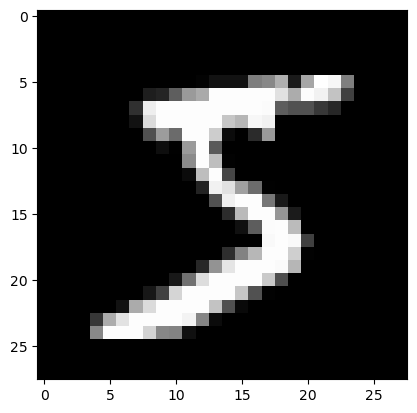

In [6]:
# Get the 0th row, all columns after the first
px_values_1d = df_digits.iloc[0,1:]

# Reshape as 2D iamge
px_values_2d = np.reshape(px_values_1d, (28,28))

# Plot the digit with gray colormap
plt.imshow(px_values_2d, cmap='gray')

# Prepare data for training.

1. Are data missing?
2. Do the values make sense?
3. Do we have enough examples of all digits?

### Are data missing?

In [7]:
df_digits.isnull()

,label,pixel_000,pixel_001,pixel_002,pixel_003,pixel_004,pixel_005,pixel_006,pixel_007,pixel_008,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
59996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
59997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
59998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


One fast way I check that all entries in this are `False` is just to take the sum. `NumPy` automatically treats `False` as a 0 in this case.

In [8]:
np.sum(df_digits.isnull().values)

np.int64(0)

Although, technically we already knew there were no empty entries, since the`df_digits` DataFrame is all integers, and `NaN` is a float.

In [9]:
type(np.nan)

float

### Do the values otherwise look correct?

We expect only integers between 0 and 255. We confirmed they are integers and can use a built-in method to check the range of values for each pixel.

In [10]:
df_description = df_digits.describe()
df_description

,label,pixel_000,pixel_001,pixel_002,pixel_003,pixel_004,pixel_005,pixel_006,pixel_007,pixel_008,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


I'll use a plot to visually confirm that the minimum is never lower than 0, and the maximum is never higher than 255.

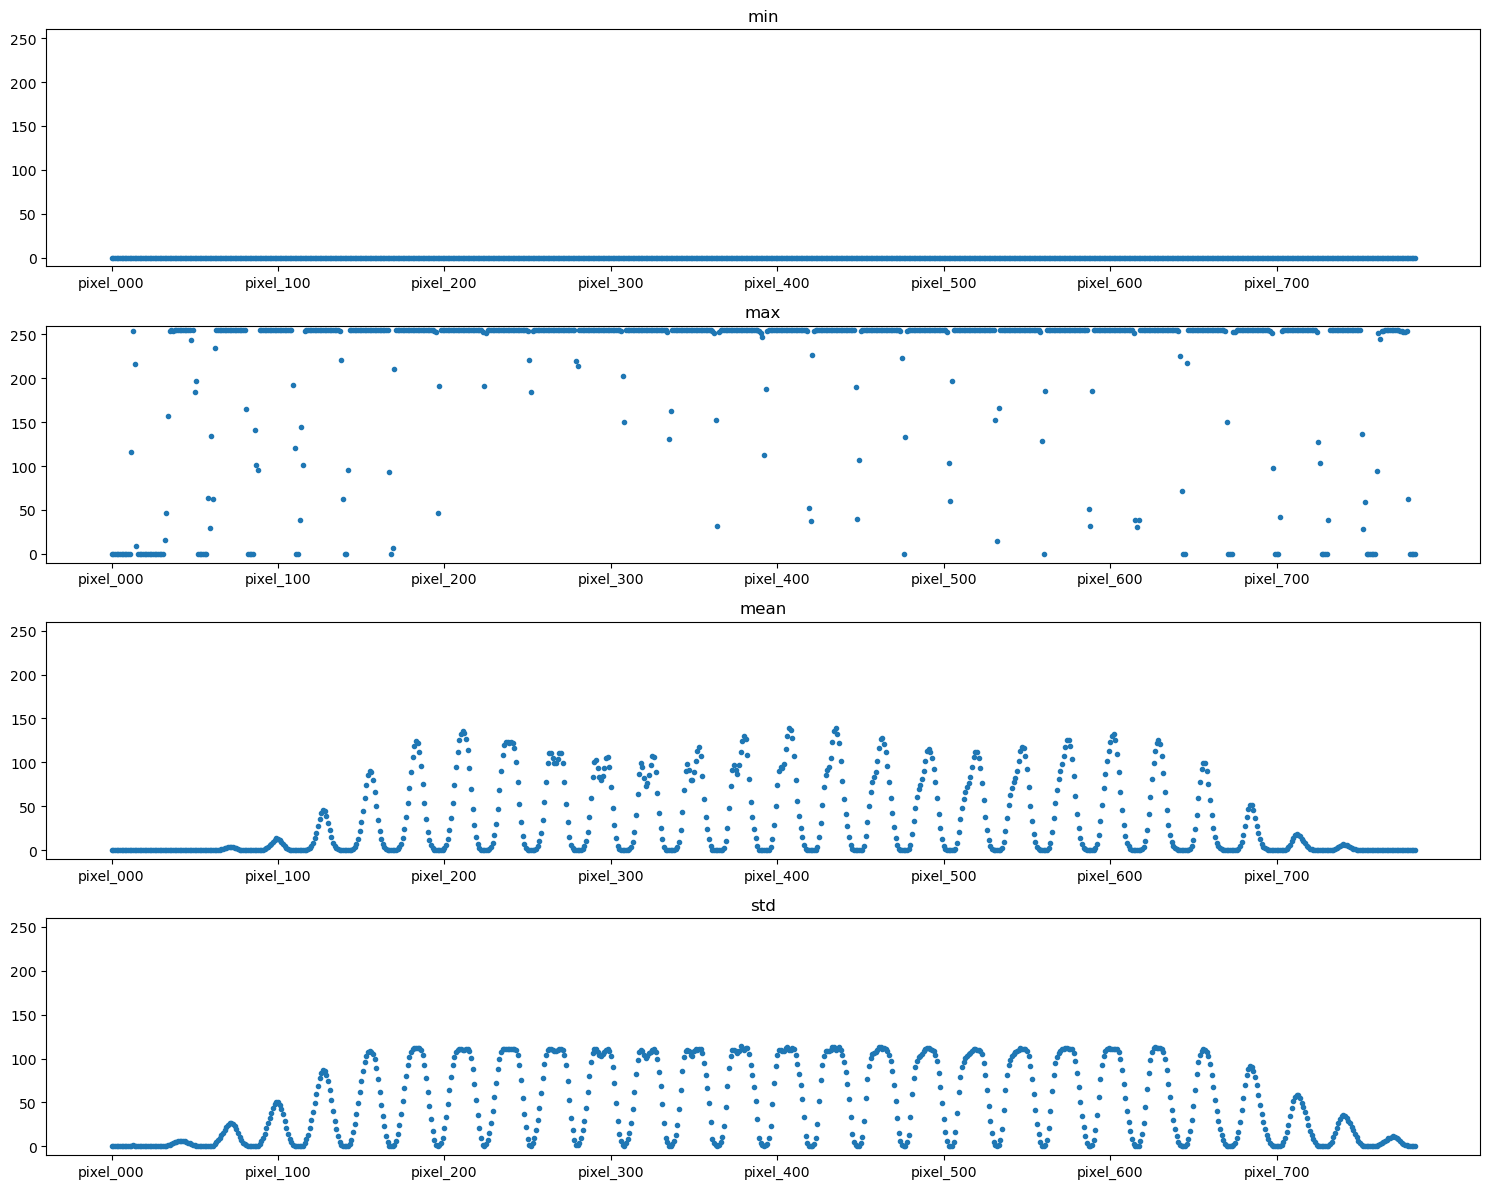

In [11]:
feature_list = ['min','max','mean','std']
fig, axes = plt.subplots(len(feature_list), 1, 
                         figsize=(15,3*len(feature_list)))

for f, feature in enumerate(feature_list):
    axes[f].plot(df_description.loc[feature][1:],'.',label=feature)
    axes[f].set_xticks(np.arange(0,800,100))
    axes[f].set_title(feature)
    axes[f].set_ylim([-10,260])
plt.tight_layout();

Note that each pixel ("feature") of the image has its own mean and standard deviation, which might indicate they have different scales, i.e., a value of 100 in one feature does not have the same magnitude as a value of 100 in another feature. However, we know here that all pixel values are on the same scale, but some pixels have more variation than others, especially in the middle. So you can rescale here to make the data more "regular," but it doesn't affect the result much.

### Do we have enough examples of all digits?

In [12]:
df_digits.label.astype('category').value_counts()

label
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64

These are all fairly similar!

Split the data to training and validation data (confusingly, both are used for training). For both training and validation data, we have the features (pixel values, "X") from which we want to get the correct classification (what digit it is, "Y").

In [13]:
# Rescaling pixel values between 0 and 1 speeds up computation and improves numerical stability
pixel_values = df_digits.iloc[:,1:] / 255
labels = df_digits.iloc[:,0]

random_seed = 67

pixels_train, pixels_validate, labels_train, labels_validate = sklearn.model_selection.train_test_split(pixel_values, labels, 
                        train_size=0.8,
                        random_state=random_seed,
                        stratify=labels 
                        )

print(f"Training set: {pixels_train.shape}")
print(f"Validation set: {pixels_validate.shape}")

Training set: (48000, 784)
Validation set: (12000, 784)


# Train a linear SVM.

First we try separating the data with a linear model.

In [14]:
# Instantiate the SVM object with kernel and C
svm_linear = sklearn.svm.SVC(kernel='linear',
                            C=0.1,
                            random_state=random_seed)

# Train / fit the model
svm_linear.fit(pixels_train, labels_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


A built-in method can check the accuracy of our model with the validation dataset.

In [15]:
# Check accuracy of prediction on validation set
accuracy_linear = svm_linear.score(pixels_validate, labels_validate)
print(f"Linear SVM Accuracy: {accuracy_linear:.4f}")

Linear SVM Accuracy: 0.9452


The overall accuracy is high, which is already a good sign. To understand where the model fails, we can look at the confusion matrix.

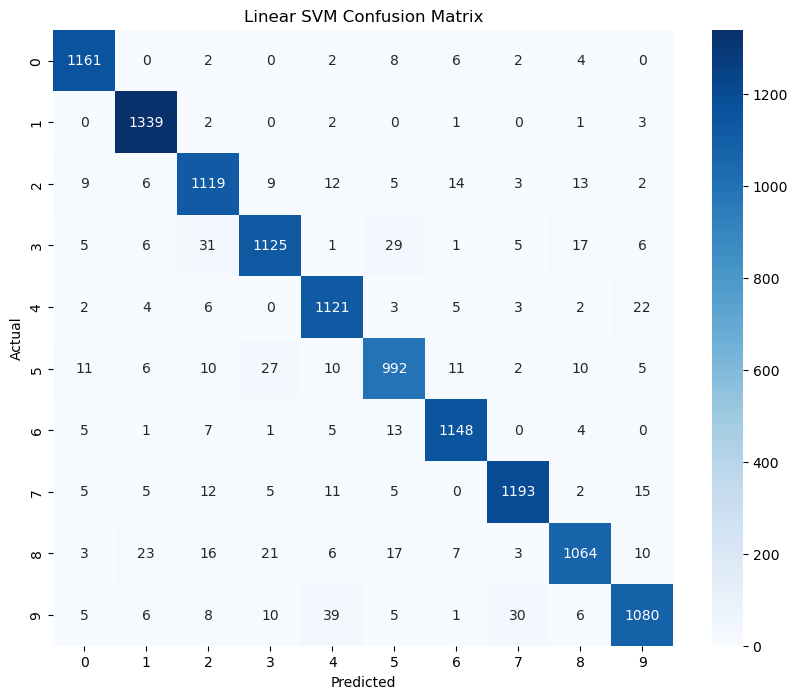

In [16]:
# Get the predicted labels for the validation set
labels_validate_linear_predict = svm_linear.predict(pixels_validate)

# Show the confusion matrix
plt.figure(figsize=(10, 8))
cm = sklearn.metrics.confusion_matrix(labels_validate, labels_validate_linear_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Linear SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Note that the confusion matrix is not symmetric! The model is much more likely to think a 9 is a 4 than to think that a 4 is a 9.

In [17]:
# Compare true and predicted labels on the validation data.
print("Classification Report (Linear SVM):")
print(sklearn.metrics.classification_report(labels_validate, labels_validate_linear_predict))

Classification Report (Linear SVM):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1185
           1       0.96      0.99      0.98      1348
           2       0.92      0.94      0.93      1192
           3       0.94      0.92      0.93      1226
           4       0.93      0.96      0.94      1168
           5       0.92      0.92      0.92      1084
           6       0.96      0.97      0.97      1184
           7       0.96      0.95      0.96      1253
           8       0.95      0.91      0.93      1170
           9       0.94      0.91      0.93      1190

    accuracy                           0.95     12000
   macro avg       0.94      0.94      0.94     12000
weighted avg       0.95      0.95      0.94     12000



We can get additional metrics from the classification report, which are also broken down by each label.

* `precision` is what fraction of the positive identifications are true positives (i.e., `tp / (tp + fp)`, where `tp` is true positive and `fp` is false positive), while `recall` is the what fraction of the data were correctly identified (i.e., `tp / (tp + fn)` where `fn` is false negative). High precision means few false positives, or that our labels are reliable. High recall means that most examples were identified. You can imagine that a model is very precise without having good recall (doesn't label everything, but what is does label is correct) or has good recall with poor precision (catches every example, but is also mislabeling other examples). These different kinds of errors could suggest different approaches for improving accuracy.
* The `f1-score` is a weighted mean of the precision and recall, essentially a way to summarize model performance in one number.
* The `support` is just the number of examples on which these numbers were calculated. The `macro avg` averages the precision and recall across all labels, while `weighted avg` gives an average weighted by the support (i.e., number of examples). 
* `accuracy`, as above, is just the number of correctly identified examples over the number of examples.

# Train a nonlinear SVM - use the RBF kernel.

Our model may be inaccurate because no linear model exists that can perfectly separate all digits. For example, it makes sense that 9 often looks like a 4.

However, there may exist a nonlinear model that can do so, which we can find by using a different "kernel," or a transformation of the data such that they are now linearly separable.

As is a common theme in machine learning and model fitting, this more complex model will require more parameters (here, support vectors) and will take longer to train. Here, we increase C (the relative importance of correct classification versus margin size) because we expect our nonlinear model to do a better job of maximizing the "margin." The new parameter $\gamma$ is computed automatically on the data when you choose `scale`, but otherwise is specified as a float.

In [18]:
# Instantiate the SVM object with kernel and C
svm_rbf = sklearn.svm.SVC(kernel='rbf',
                            C=1.0,
                             gamma='scale',
                            random_state=random_seed)

# Train / fit the model
svm_rbf.fit(pixels_train, labels_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [19]:
accuracy_rbf = svm_rbf.score(pixels_validate, labels_validate)
print(f"RBF SVM Accuracy: {accuracy_rbf:.4f}")

RBF SVM Accuracy: 0.9798


We can also plot the confusion matrix and look at the classification report.

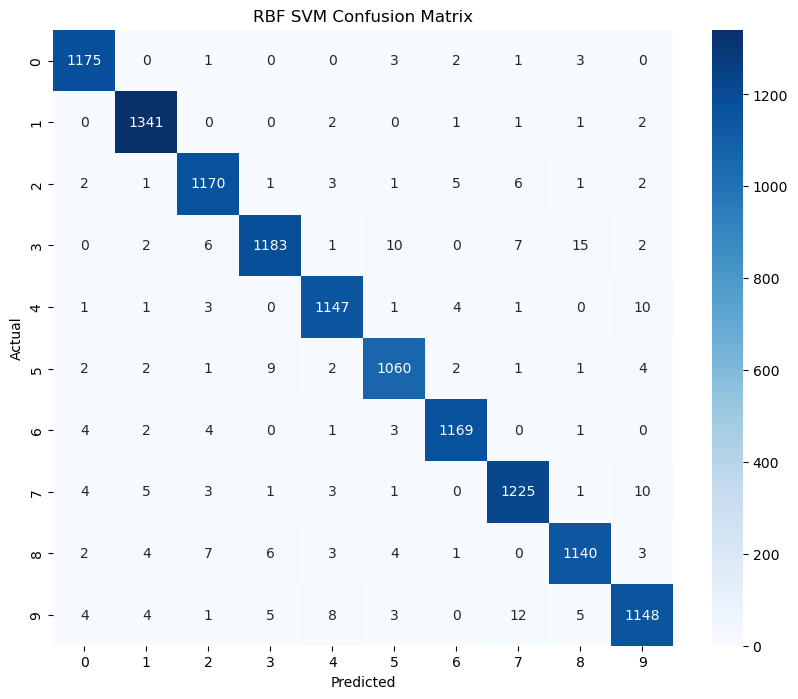

In [20]:
# Get the predicted labels for the validation set
labels_validate_rbf_predict = svm_rbf.predict(pixels_validate)

# Show the confusion Matrix
plt.figure(figsize=(10, 8))
cm = sklearn.metrics.confusion_matrix(labels_validate, labels_validate_rbf_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('RBF SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [21]:
# Compare true and predicted labels on the validation data.
print("Classification Report (RBF SVM):")
print(sklearn.metrics.classification_report(labels_validate, labels_validate_rbf_predict))

Classification Report (RBF SVM):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1185
           1       0.98      0.99      0.99      1348
           2       0.98      0.98      0.98      1192
           3       0.98      0.96      0.97      1226
           4       0.98      0.98      0.98      1168
           5       0.98      0.98      0.98      1084
           6       0.99      0.99      0.99      1184
           7       0.98      0.98      0.98      1253
           8       0.98      0.97      0.98      1170
           9       0.97      0.96      0.97      1190

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000



# Improve model accuracy with hyperparameter tuning

We have already seen that choosing a different model can improve fitting (i.e., prediction). But we also know that we are solving an optimization problem, where $C$ and $\gamma$ are part of the expression we are optimizing. There may be values of those hyperparameters that could produce _even better_ models.

Here is where using the validation set is valuable. We can train a bunch of different models on the same training data, but then pick our favorite model by seeing which does best on the validation data. Then we report the final model accuracy by checking its performance on the test set, which has truly never been part of the model training.

For this grid search, we try three different values for each of our hyperparameters: 3 for $C$ and 3 for $\gamma$. For each hyperparameter set, `sklearn` will fit the data a few different times to understand its average performance (i.e., perform cross validation). For `cv=3`, the data is split into thirds. It then fits the data three times, each time leaving out one of those thirds and training on the other two. The performance is then the average of the those three models' performance.

Since this means we will train 27 models, let's reduce the training set size to speed things up.

In [22]:
train_size = 0.1 # Percentage of data to include for grid search

pixels_train_cv, pixels_validate_cv, labels_train_cv, labels_validate_cv = sklearn.model_selection.train_test_split(pixel_values, labels, 
                        train_size=train_size,
                        random_state=random_seed,
                        stratify=labels 
                        )

In [23]:
parameters = {'C': [0.1, 1, 10],
             'gamma': ['scale', 0.01, 0.1]}

# Instantiate the model
svc_rbf_grid_search = sklearn.svm.SVC(kernel='rbf', random_state=random_seed)

# Instantiate the grid search, using the model and kwargs for how to do grid search
grid_search = sklearn.model_selection.GridSearchCV(svc_rbf_grid_search,
                            parameters,
                            cv=3,
                            n_jobs=-1,
                            return_train_score=True)

# Run the grid search
grid_search.fit(pixels_train_cv, labels_train_cv);

In [24]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'C': 10, 'gamma': 'scale'}
Best CV accuracy: 0.9665


In [25]:
cv_results = pd.DataFrame(grid_search.cv_results_)

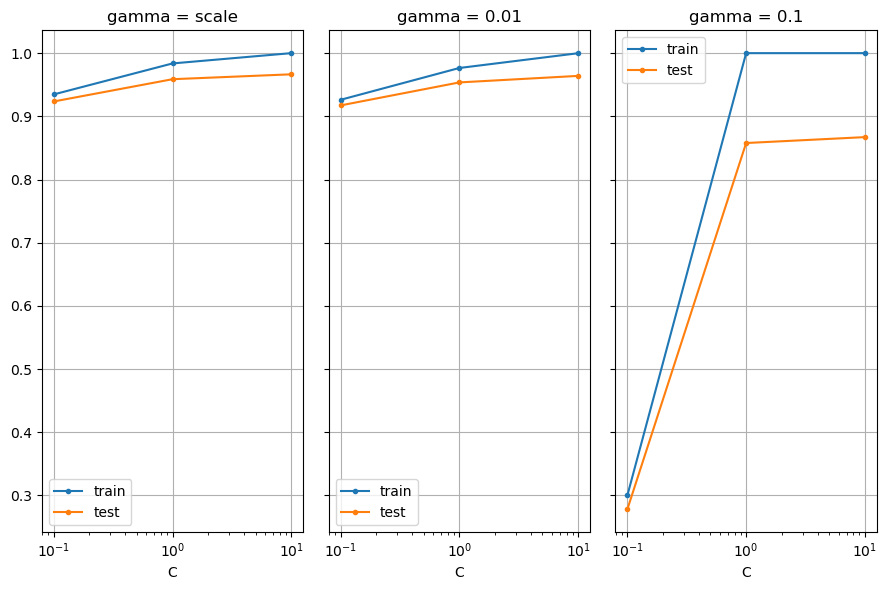

In [26]:
n_gamma = len(parameters['gamma'])
fig, axes = plt.subplots(1,n_gamma, 
                         sharey=True,
                        figsize=(3*n_gamma,6))

for g, param_gamma in enumerate(parameters['gamma']):
    df_g = cv_results.loc[cv_results['param_gamma']==param_gamma]

    for dataset in ['train','test']:
        axes[g].plot(df_g['param_C'],
                 df_g[f'mean_{dataset}_score'],
                 '.-',
                 label=dataset)

    axes[g].set_xscale('log')
    axes[g].set_xlabel('C')
    axes[g].set_title(f'gamma = {param_gamma}')
    axes[g].legend()
    axes[g].grid(True)
    
plt.tight_layout()
        

Here we see that model performance is always worse in the test set, likely because the model hasn't been explicitly trained on those examples. Increasing $C$, the penalty for misclassification, increases model accuracy. However, particularly for smaller values of $\gamma$, you see that higher $C$ lowers error on the training data without necessarily improving generalization (i.e., how well it performs on the test data).

### Train with best-possible hyperparameters

In [27]:
# Instantiate the SVM object with kernel and C
svm_rbf_besthp = sklearn.svm.SVC(kernel='rbf',
                            C=10,
                             gamma='scale',
                            random_state=random_seed)

# Train / fit the model
svm_rbf_besthp.fit(pixels_train, labels_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
accuracy_rbf_besthp = svm_rbf_besthp.score(pixels_validate, labels_validate)
print(f"RBF SVM Accuracy: {accuracy_rbf_besthp:.4f}")

RBF SVM Accuracy: 0.9858


We indeed see a .5% increase in accuracy. This in practice is not much, but if we were classifying a lot of digits every day, maybe it would be valuable to generate fewer errors. Note that this is higher than the accuracy we got in our parameter screen, but this is because the parameter screen trained only on a subset of the data.

# Future exploration

* Run the grid search on parameter C - is it possible to make the linear model perform as well as RBF?
* Check out the SVM weights to see if you can interprethow the model distinguishes digits from each other.
* Repeat the grid search, but with the full dataset and/or the full training set. Do you get the same result for the best hyper parameters?

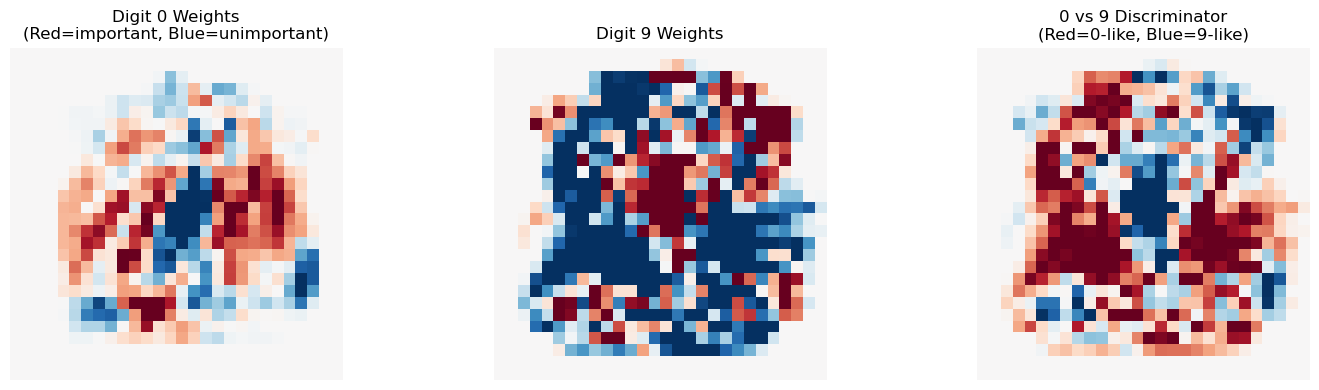

In [30]:
# Only works for LINEAR SVM!
svm_linear_interpretable = sklearn.svm.SVC(kernel='linear', C=0.1)
svm_linear_interpretable.fit(pixels_train_cv, labels_train_cv)

# Plot weights for digits 0 vs 9 comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Digit 0 weights
w0 = svm_linear_interpretable.coef_[0].reshape(28, 28)  # Class 0's 784 weights → 28×28 image
axes[0].imshow(w0, cmap='RdBu_r', vmin=-0.1, vmax=0.1)
axes[0].set_title('Digit 0 Weights\n(Red=important, Blue=unimportant)')
axes[0].axis('off')

# Digit 9 weights  
w9 = svm_linear.coef_[9].reshape(28, 28)
axes[1].imshow(w9, cmap='RdBu_r', vmin=-0.1, vmax=0.1)
axes[1].set_title('Digit 9 Weights')
axes[1].axis('off')

# Difference (0 vs 9 discriminator)
axes[2].imshow((w0 - w9), cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[2].set_title('0 vs 9 Discriminator\n(Red=0-like, Blue=9-like)')
axes[2].axis('off')

plt.tight_layout()
plt.show()